 # Analyzing the Correlation Between Surprising Match Results and X Tweet Engagement Levels for English Premier League Clubs in the 2025-2026 Season
DSCI 510 – Principles of Programming for Data Science

Nanpu Chen - University of Southern California – Spring 2026

This project investigates whether surprising English Premier League (hereinafter referred to as “EPL”) match outcomes influence engagement levels on EPL club’s official X (formerly Twitter) account. Pre-match betting odds will be used to determine expected match results and actual match results will be compared to identify whether the result is a surprising win, an expected result, or a surprising loss. Engagement level is analyzed by collecting certain metrics (likes, retweets, and replies) from post-match posts of the clubs’ main official X account. The study aims to evaluate whether unexpected match results correlate with EPL clubs’ social media engagement.

## 0.Setup

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

from config import *
sys.path.append(os.path.abspath("src"))
from main import main

## 1. Load Dataset

main(season, threshold) runs the full pipeline and generates the final dataset which contains the engagement lift levels of each club after each game. "season" so far only works for 2025/26 season. threshold is default set to 0.35 but can be customized.

In [57]:
club_df = main(2025, threshold=0.35)
club_df.head()

Droped 67 entries


,club,opponent,kickoff_time,surprise,engagement_changes
0,Bournemouth,Liverpool,2025-08-15 19:00:00+00:00,expected,68884.583333
1,Newcastle,Aston Villa,2025-08-16 11:30:00+00:00,surprise_draw,-1275.538462
2,Brighton,Fulham,2025-08-16 14:00:00+00:00,surprise_draw,1383.391534
3,Fulham,Brighton,2025-08-16 14:00:00+00:00,surprise_draw,638.663158
4,West Ham United,Sunderland,2025-08-16 14:00:00+00:00,surprise_loss,6898.204545


## 2. Data Overview and Cleaning

Checks whether the dataset has columns we needed and whether there are any NaN values needed to be fixed

In [48]:
print("Size:", club_df.shape,"\n")
print("Data types:")
print(club_df.dtypes)
print("\nNaN values:")
print(club_df.isna().sum())

Size: (591, 5) 

Data types:
club                                  str
opponent                              str
kickoff_time          datetime64[us, UTC]
surprise                              str
engagement_changes                float64
dtype: object

NaN values:
club                  0
opponent              0
kickoff_time          0
surprise              0
engagement_changes    0
dtype: int64


In [49]:
club_df.describe()
club_df["surprise"].value_counts()

surprise
expected         305
surprise_draw    166
surprise_win      64
surprise_loss     56
Name: count, dtype: int64

## 3. Visualizations

### 3.1 Average Engagement Lift by Surprise Category

In [50]:
avg_lift = club_df.groupby("surprise")["engagement_changes"].mean()
avg_lift

surprise
expected         3854.508376
surprise_draw    1707.427373
surprise_loss    4454.419305
surprise_win     6641.453722
Name: engagement_changes, dtype: float64

### 3.2 Engagement change by surprise category — boxplot

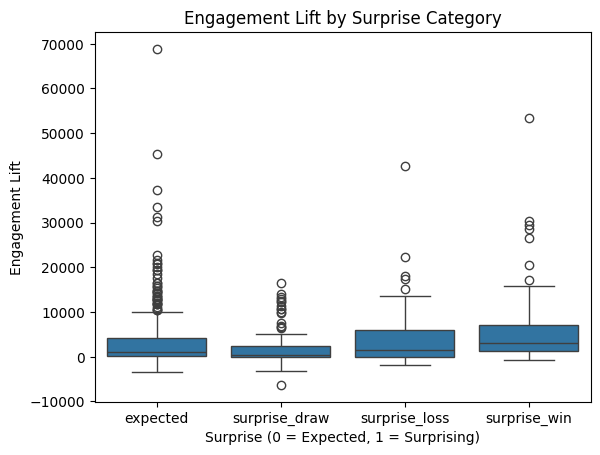

In [51]:
sns.boxplot(x="surprise", y="engagement_changes", data=club_df)

plt.title("Engagement Lift by Surprise Category")
plt.xlabel("Surprise (0 = Expected, 1 = Surprising)")
plt.ylabel("Engagement Lift")
plt.show()

### 3.3 Club-level Heatmap

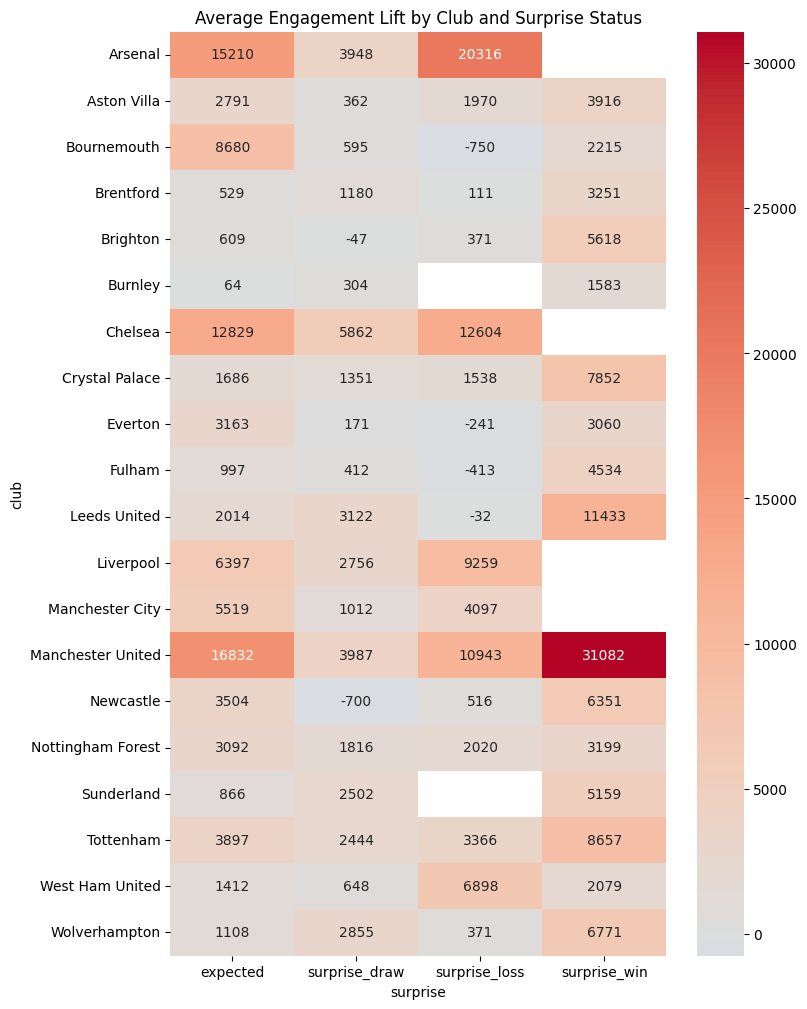

In [52]:
heatmap_data = (
    club_df
    .groupby(["club", "surprise"])["engagement_changes"]
    .mean()
    .reset_index()
    .pivot(index="club", columns="surprise", values="engagement_changes")
)

plt.figure(figsize=(8,12))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="coolwarm", center=0)
plt.title("Average Engagement Lift by Club and Surprise Status")
plt.show()

### 3.4 Correlation Pairplot

In [53]:
club_df

,club,opponent,kickoff_time,surprise,engagement_changes
0,Bournemouth,Liverpool,2025-08-15 19:00:00+00:00,expected,68884.583333
1,Newcastle,Aston Villa,2025-08-16 11:30:00+00:00,surprise_draw,-1275.538462
2,Brighton,Fulham,2025-08-16 14:00:00+00:00,surprise_draw,1383.391534
3,Fulham,Brighton,2025-08-16 14:00:00+00:00,surprise_draw,638.663158
4,West Ham United,Sunderland,2025-08-16 14:00:00+00:00,surprise_loss,6898.204545
...,...,...,...,...,...
586,Liverpool,Everton,2026-04-19 13:00:00+00:00,expected,10525.461538
587,Manchester City,Arsenal,2026-04-19 15:30:00+00:00,expected,11848.242424
588,Arsenal,Manchester City,2026-04-19 15:30:00+00:00,expected,19321.019608
589,Crystal Palace,West Ham United,2026-04-20 19:00:00+00:00,surprise_draw,254.333333
